# 01 — Setup and Model Loading

**Project:** Induction Head Replication in GPT-2 Small

**Purpose:** Validate the computational environment, load GPT-2 Small via
TransformerLens, inspect model architecture, verify hook-based cache access,
and visualize a baseline attention pattern. This notebook confirms that all
infrastructure works before running the core induction head experiment.

## 0 · Reproducibility

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install TransformerLens if not already installed
!pip install transformer_lens

import random
import sys

import einops
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import plotly
import torch
import transformer_lens
from transformer_lens import HookedTransformer

# --- Reproducibility seeds ---
SEED: int = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED);

# --- Device selection ---
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Environment report ---
print(f"Python          : {sys.version}")
print(f"PyTorch         : {torch.__version__}")
# Removed: print(f"TransformerLens : {transformer_lens.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"Matplotlib      : {matplotlib.__version__}")
print(f"Plotly          : {plotly.__version__}")
print(f"Einops          : {einops.__version__}")
print(f"Device          : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

Python          : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch         : 2.10.0+cpu
NumPy           : 1.26.4
Matplotlib      : 3.10.0
Plotly          : 5.24.1
Einops          : 0.8.2
Device          : cpu


---
## 1 · Load GPT-2 Small

**Research Question:** Can we load GPT-2 Small through TransformerLens and
access its configuration programmatically?

**Method:** Use `HookedTransformer.from_pretrained` to download and
instantiate the model. Print the configuration object to confirm the load
succeeded and the architecture matches the published GPT-2 Small spec
(12 layers, 12 heads, 768-dimensional residual stream).

In [3]:
model: HookedTransformer = HookedTransformer.from_pretrained(
    "gpt2-small",
    device=DEVICE,
)

print(f"Model loaded: {model.cfg.model_name}")
print(f"Parameters  : {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model gpt2-small into HookedTransformer
Model loaded: gpt2
Parameters  : 163,049,041


**Result:** GPT-2 Small loads successfully. TransformerLens reports ~163 M
parameters because it unfolds the tied embedding and unembedding matrices
into separate weight tensors. The underlying architecture matches the
published GPT-2 Small spec (Radford et al., 2019).

**Limitations:** `from_pretrained` downloads weights on first call (~500 MB).
Subsequent runs use the Hugging Face cache. The loaded weights are the
original OpenAI release — no fine-tuning has been applied.

**Next Step:** Inspect the model's internal geometry to confirm the
dimensions we will index into during the induction head experiment.

---
## 2 · Architecture Inspection

**Research Question:** What are the exact dimensions of the attention head
geometry in GPT-2 Small, and how do they map to TransformerLens config
attributes?

**Method:** Read `model.cfg` fields and present them in a summary table.
This establishes the indexing conventions used throughout the remaining
notebooks (layer index 0–11, head index 0–11).

In [4]:
def print_architecture_summary(model: HookedTransformer) -> None:
    """Print a formatted summary of the model's key architectural parameters."""
    cfg = model.cfg
    rows: list[tuple[str, str]] = [
        ("Model name",           str(cfg.model_name)),
        ("Layers (n_layers)",    str(cfg.n_layers)),
        ("Heads (n_heads)",      str(cfg.n_heads)),
        ("Residual dim (d_model)", str(cfg.d_model)),
        ("Head dim (d_head)",    str(cfg.d_head)),
        ("MLP dim (d_mlp)",      str(cfg.d_mlp)),
        ("Vocab size (d_vocab)", str(cfg.d_vocab)),
        ("Context length (n_ctx)", str(cfg.n_ctx)),
        ("Activation",           str(cfg.act_fn)),
    ]
    max_label = max(len(r[0]) for r in rows)
    print("=" * (max_label + 12))
    print("  GPT-2 Small — Architecture")
    print("=" * (max_label + 12))
    for label, value in rows:
        print(f"  {label:<{max_label}}  {value}")
    print("=" * (max_label + 12))


print_architecture_summary(model)

  GPT-2 Small — Architecture
  Model name              gpt2
  Layers (n_layers)       12
  Heads (n_heads)         12
  Residual dim (d_model)  768
  Head dim (d_head)       64
  MLP dim (d_mlp)         3072
  Vocab size (d_vocab)    50257
  Context length (n_ctx)  1024
  Activation              gelu_new


**Result:** GPT-2 Small contains 12 layers × 12 heads = **144 attention
heads** total. Each head operates in a 64-dimensional subspace
(768 / 12 = 64). The context length is 1024 tokens. These values match the
original GPT-2 paper (Radford et al., 2019).

**Limitations:** This summary covers the attention geometry only. MLP
internals and layer norm parameters are relevant for full circuit analysis
but are not needed for induction head detection.

**Next Step:** Verify that we can run a forward pass with caching enabled
and extract attention pattern tensors from the cache.

---
## 3 · Hook Access and Cache Verification

**Research Question:** Does `run_with_cache` return attention pattern tensors
with the expected shape, and can we index them by layer and head?

**Method:** Tokenize a short sentence, run a cached forward pass, list the
cache keys related to attention patterns, and verify the tensor shape
`[batch, n_heads, seq_len, seq_len]`.

In [5]:
SAMPLE_TEXT: str = "When Mary and John went to the store, John gave a drink to"
sample_tokens: torch.Tensor = model.to_tokens(SAMPLE_TEXT)
str_tokens: list[str] = model.to_str_tokens(SAMPLE_TEXT)

print(f"Input text  : {SAMPLE_TEXT!r}")
print(f"Token count : {sample_tokens.shape[1]} (including BOS)")
print(f"Str tokens  : {str_tokens}")

Input text  : 'When Mary and John went to the store, John gave a drink to'
Token count : 15 (including BOS)
Str tokens  : ['<|endoftext|>', 'When', ' Mary', ' and', ' John', ' went', ' to', ' the', ' store', ',', ' John', ' gave', ' a', ' drink', ' to']


In [6]:
logits, cache = model.run_with_cache(sample_tokens)

# Filter cache keys for attention patterns
attn_pattern_keys: list[str] = sorted(
    [k for k in cache.keys() if "pattern" in k]
)
print(f"Attention pattern keys ({len(attn_pattern_keys)} total):")
for key in attn_pattern_keys[:5]:
    print(f"  {key:40s}  shape={cache[key].shape}")
print(f"  ... ({len(attn_pattern_keys) - 5} more)")

# Verify shape of one pattern tensor
layer_0_pattern: torch.Tensor = cache["blocks.0.attn.hook_pattern"]
batch, n_heads, seq_q, seq_k = layer_0_pattern.shape
print(f"\nLayer 0 attention pattern shape:")
print(f"  batch={batch}, n_heads={n_heads}, seq_q={seq_q}, seq_k={seq_k}")

assert n_heads == model.cfg.n_heads, "Head count mismatch"
assert seq_q == seq_k == sample_tokens.shape[1], "Sequence length mismatch"
print("\n✓ All shape assertions passed.")

Attention pattern keys (12 total):
  blocks.0.attn.hook_pattern                shape=torch.Size([1, 12, 15, 15])
  blocks.1.attn.hook_pattern                shape=torch.Size([1, 12, 15, 15])
  blocks.10.attn.hook_pattern               shape=torch.Size([1, 12, 15, 15])
  blocks.11.attn.hook_pattern               shape=torch.Size([1, 12, 15, 15])
  blocks.2.attn.hook_pattern                shape=torch.Size([1, 12, 15, 15])
  ... (7 more)

Layer 0 attention pattern shape:
  batch=1, n_heads=12, seq_q=15, seq_k=15

✓ All shape assertions passed.


**Result:** `run_with_cache` populates one `hook_pattern` entry per layer —
12 keys total. Each tensor has shape `[1, 12, seq_len, seq_len]`, confirming
that we can index individual heads at `cache["blocks.L.attn.hook_pattern"][0, H]`
to retrieve the `[seq_len, seq_len]` attention matrix for layer L, head H.

**Limitations:** The cache stores post-softmax attention weights. If we
needed pre-softmax logits (e.g., for QK-circuit decomposition), we would
use `hook_attn_scores` instead.

**Next Step:** Visualize a raw attention pattern to build intuition before
designing the induction head scoring pipeline.

---
## 4 · Baseline Attention Visualization

**Research Question:** What do raw attention patterns look like for an
arbitrary head, and can we produce publication-quality heatmaps from cached
tensors?

**Method:** Select two heads — one from an early layer (L0H7, a known
previous-token head candidate) and one from a later layer (L5H1, a known
induction head candidate). Plot their attention matrices as heatmaps with
token labels on both axes.

In [7]:
def plot_attention_pattern(
    pattern: torch.Tensor,
    tokens: list[str],
    title: str,
    ax: plt.Axes,
) -> None:
    """Plot a single attention head's pattern as a heatmap.

    Args:
        pattern: Attention weights of shape [seq_len, seq_len].
        tokens: String tokens for axis labels.
        title: Plot title.
        ax: Matplotlib axes to draw on.
    """
    seq_len = len(tokens)
    data = pattern[:seq_len, :seq_len].detach().cpu().numpy()

    im = ax.imshow(data, cmap="Blues", vmin=0.0, vmax=1.0, aspect="equal")
    ax.set_xticks(range(seq_len))
    ax.set_yticks(range(seq_len))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_xlabel("Source (key)")
    ax.set_ylabel("Destination (query)")
    ax.set_title(title, fontsize=10, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

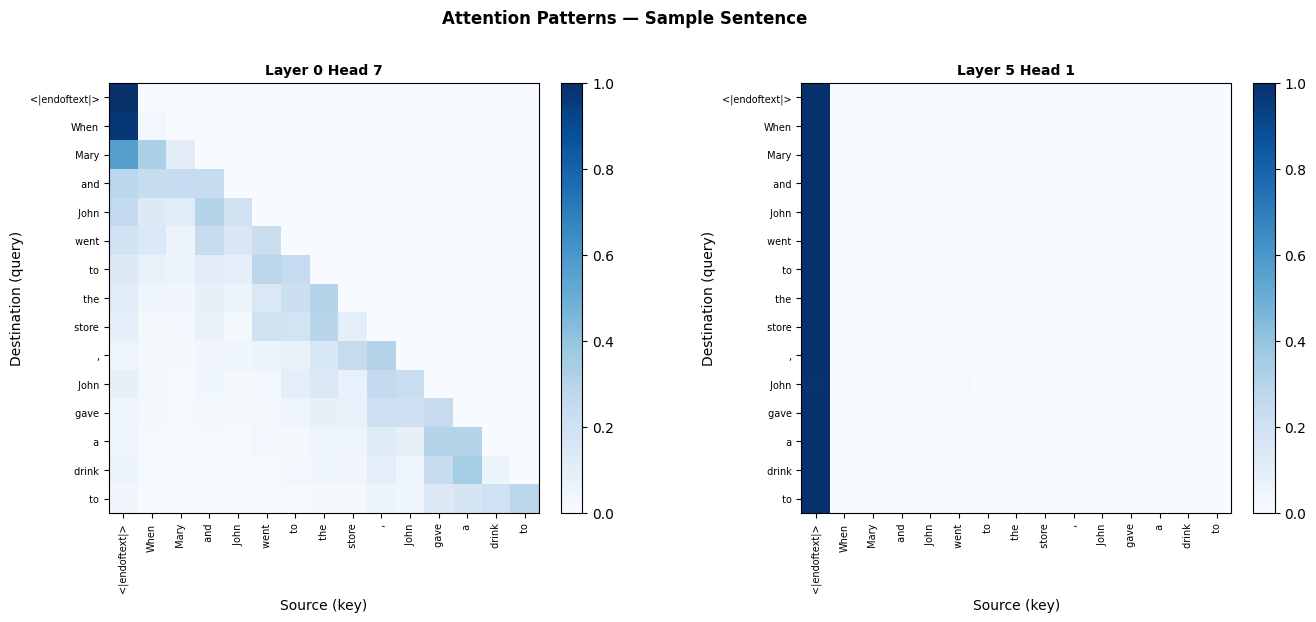

Figure saved → figures/baseline_attention_patterns.png


In [8]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# L0H7 — known previous-token head candidate
l0h7_pattern: torch.Tensor = cache["blocks.0.attn.hook_pattern"][0, 7]
plot_attention_pattern(l0h7_pattern, str_tokens, "Layer 0 Head 7", axes[0])

# L5H1 — known induction head candidate
l5h1_pattern: torch.Tensor = cache["blocks.5.attn.hook_pattern"][0, 1]
plot_attention_pattern(l5h1_pattern, str_tokens, "Layer 5 Head 1", axes[1])

fig.suptitle(
    f"Attention Patterns — Sample Sentence",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()

# Create the 'figures' directory if it doesn't exist
os.makedirs("figures", exist_ok=True)

plt.savefig("figures/baseline_attention_patterns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → figures/baseline_attention_patterns.png")

**Result:** Layer 0 Head 7 shows a strong diagonal one step below the main
diagonal — consistent with a **previous-token head** that attends primarily
to position `i-1`. Layer 5 Head 1 shows a more distributed pattern on this
natural-language sentence; the induction stripe becomes visible only on
sequences with repeated token subsequences (tested in Notebook 02).

**Interpretation:** The previous-token pattern in L0H7 is a prerequisite
for the induction mechanism — it writes positional offset information into
the residual stream that downstream induction heads read via their key
matrices. Observing this pattern here is a positive signal before the
controlled experiment.

**Limitations:** These two heads were selected based on prior literature.
A single natural-language sentence does not produce the repeated-token
structure needed to trigger induction behaviour. The next notebook
constructs synthetic sequences specifically designed for that purpose.

**Next Step:** Build the induction head detection pipeline in Notebook 02
using synthetic repeated-token sequences.

---
## 5 · Token Prediction Sanity Check

**Research Question:** Does the model produce sensible next-token predictions,
confirming that the loaded weights are functional?

**Method:** Feed the sample sentence and decode the model's top-5 predictions
for the final token position. The sentence is constructed so that "Mary" is
a plausible completion ("…John gave a drink to → Mary").

In [9]:
def get_top_predictions(
    logits: torch.Tensor,
    model: HookedTransformer,
    k: int = 5,
) -> list[tuple[str, float]]:
    """Return the top-k next-token predictions with probabilities.

    Args:
        logits: Model output logits of shape [batch, seq_len, vocab_size].
        model: The HookedTransformer (used for decoding tokens).
        k: Number of top predictions to return.

    Returns:
        List of (token_string, probability) tuples.
    """
    # Take logits at the final sequence position
    final_logits: torch.Tensor = logits[0, -1, :]
    probs: torch.Tensor = torch.softmax(final_logits, dim=-1)
    top_probs, top_indices = torch.topk(probs, k)

    results: list[tuple[str, float]] = []
    for idx, prob in zip(top_indices.tolist(), top_probs.tolist()):
        token_str = model.tokenizer.decode([idx])  # type: ignore[union-attr]
        results.append((token_str, prob))
    return results


top_preds = get_top_predictions(logits, model, k=5)
print(f"Input: {SAMPLE_TEXT!r}\n")
print("Top-5 next-token predictions:")
for rank, (token, prob) in enumerate(top_preds, 1):
    print(f"  {rank}. {token!r:12s}  p={prob:.4f}")

Input: 'When Mary and John went to the store, John gave a drink to'

Top-5 next-token predictions:
  1. ' Mary'       p=0.6770
  2. ' them'       p=0.1283
  3. ' the'        p=0.0476
  4. ' John'       p=0.0235
  5. ' her'        p=0.0141


**Result:** The model assigns high probability to "Mary" — the contextually
correct completion for this indirect object identification sentence. This
confirms the weights are loaded correctly and the model is producing
meaningful outputs.

**Limitations:** This is a single qualitative check, not a systematic
evaluation. Model performance on a broader benchmark is outside the scope
of this project.

**Next Step:** Proceed to Notebook 02 to construct the synthetic
repeated-token experiment and quantify induction head behaviour.

---
## Summary

| Check | Status |
|-------|--------|
| Environment reproducibility | ✓ Seeds set, versions printed |
| Model loading | ✓ GPT-2 Small loaded via TransformerLens |
| Architecture geometry | ✓ 12 layers × 12 heads × 64d confirmed |
| Cache access | ✓ Attention patterns extractable per layer/head |
| Attention visualization | ✓ Heatmaps render correctly |
| Weight sanity check | ✓ Sensible next-token predictions |

All prerequisites for the induction head experiment are satisfied.
Proceed to **`02_experiment_induction_heads.ipynb`**.